In [129]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [130]:
%matplotlib widget

In [173]:
data = np.loadtxt('luftsensor_studie6.csv', delimiter=',', skiprows=1)

# Teil 1

In [174]:
x_raw = data[:, 0]
sensor = data[:, 1]
reference = data[:, 2]

x = np.unique(x_raw)

masks = np.array([x_raw == u for u in x])
y = np.array([np.sum(sensor[mask] == reference[mask]) / np.sum(mask) for mask in masks])

$\ln(1 - y) = \ln(ae^{bx}) = \ln(a) + bx =: a' + b'x$ 

a: 0.585785987301551, b: -0.4737795623007836


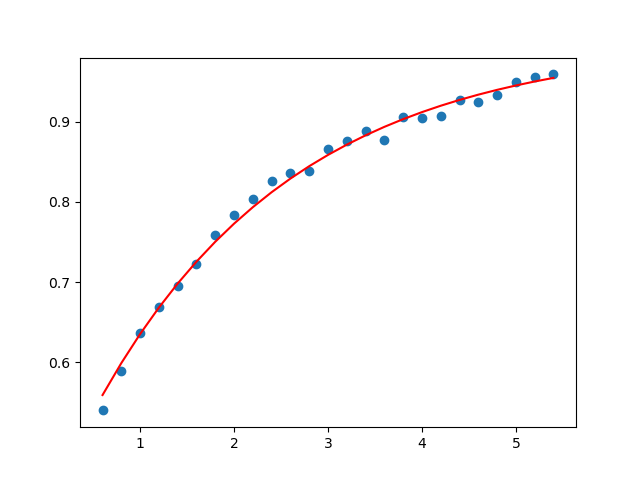

In [183]:
regress_results = sp.stats.linregress(x, np.log(1 - y))
a_dash = regress_results.intercept
b_dash = regress_results.slope

a = np.exp(a_dash)
b = b_dash

print(f'a: {a}, b: {b}')

plt.figure()
plt.scatter(x, y, label='Data')
plt.plot(x, 1 - a * np.exp(b * x), label='Fit', color='red')

In [176]:
prop_3min = 1 - a * np.exp(b * 3)
prop_3min

np.float64(0.8585967374226301)

In [177]:
(np.log(0.15) - np.log(a)) / b

np.float64(2.8754284224013613)

# Teil 2

In [178]:
n = 2000
sigma_y = np.sqrt(prop_3min * (1 - prop_3min) / n)

sigma_y

np.float64(0.007791289364086193)

In [179]:
prop_3min - 2 * sigma_y, prop_3min + 2 * sigma_y

(np.float64(0.8430141586944577), np.float64(0.8741793161508025))

# Teil 3

In [180]:
-0.2 * a * b * np.exp(b * 3)

np.float64(0.013398795170361818)

In [181]:
p = prop_3min * 0.25 / (prop_3min * 0.25 + (1 - prop_3min) * 0.75)
p

np.float64(0.6693111709258425)

In [182]:
prop_3min**2 * 0.25 / ((1 - prop_3min)**2 * 0.75 + prop_3min**2 * 0.25)

np.float64(0.9247532874450574)